# Bayesian GMM — Active Regime Count (pmr_paper)

Dirichlet-process mixture on standardized `data/features.csv`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


def _find_pmr_root() -> Path:
    """Locate pmr_paper/ from the notebook working directory."""
    start = Path.cwd().resolve()
    for parent in [start, *start.parents]:
        if (parent / "scripts" / "paths.py").is_file():
            return parent
    raise FileNotFoundError(
        "Could not locate pmr_paper (scripts/paths.py not found). "
        "Run this notebook from inside the pmr_paper tree."
    )


PROJECT_ROOT = _find_pmr_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.paths import FEATURES_PATH, load_features

features = load_features()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features.values)

print(f"Project root: {PROJECT_ROOT}")
print(f"Features: {FEATURES_PATH}")
print(f"Shape after cleaning: {features.shape}")


from scripts.bayesian import get_active_regimes


Project root: /Users/antoinea/Desktop/Master_Thesis
Features: /Users/antoinea/Desktop/Master_Thesis/data/features.csv
Shape after cleaning: (663, 17)


The Bayesian GMM initialized with 10 maximum regimes.
Number of 'Active' regimes (weight > 4.0%): 4


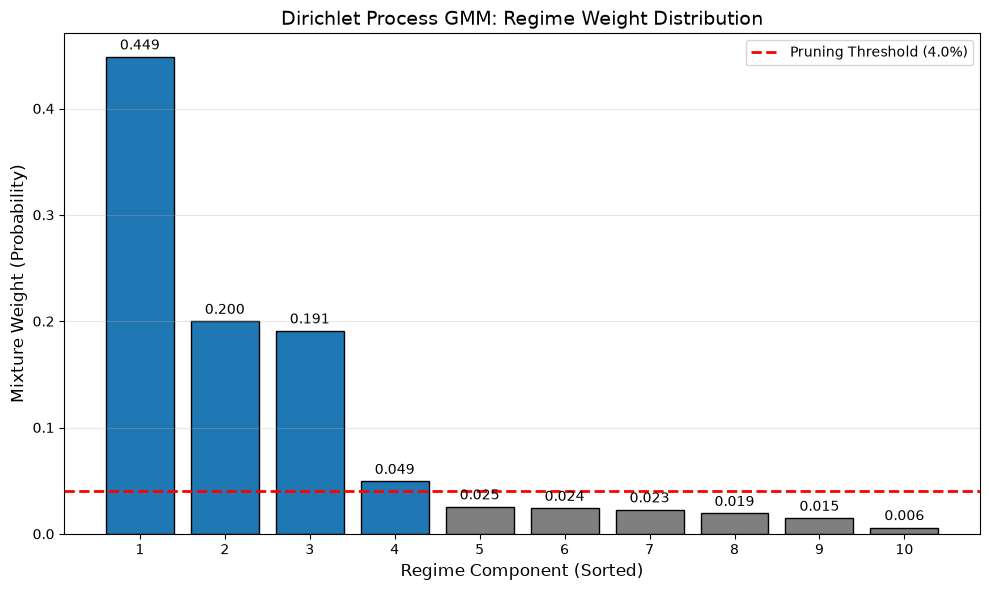

In [2]:
# Parameters
MAX_COMPONENTS = 10
THRESHOLD = 0.04
ALPHA_PRIOR = 0.1

# Fit the model (using 'full' covariance because we are using the full dataset)
active_k, weights = get_active_regimes(
    data=X_scaled, 
    max_components=MAX_COMPONENTS, 
    weight_threshold=THRESHOLD, 
    covariance_type='full',  # Full sample allows full covariance
    random_state=42,          # Fixed for reproducible thesis plot
    alpha_prior=ALPHA_PRIOR
)

print(f"The Bayesian GMM initialized with {MAX_COMPONENTS} maximum regimes.")
print(f"Number of 'Active' regimes (weight > {THRESHOLD*100}%): {active_k}")

# Sort weights in descending order for the "Scree Plot" look
sorted_weights = np.sort(weights)[::-1]

# Assign colors: Blue for active, Gray for pruned
colors = ['tab:blue' if w > THRESHOLD else 'tab:gray' for w in sorted_weights]

# Create the visualization
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(1, MAX_COMPONENTS + 1), sorted_weights, color=colors, edgecolor='black')

# Add the threshold line
ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Pruning Threshold ({THRESHOLD*100}%)')

# Formatting
ax.set_title("Dirichlet Process GMM: Regime Weight Distribution", fontsize=14)
ax.set_xlabel("Regime Component (Sorted)", fontsize=12)
ax.set_ylabel("Mixture Weight (Probability)", fontsize=12)
ax.set_xticks(range(1, MAX_COMPONENTS + 1))
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add text labels on top of the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()